In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import calendar

import xarray as xr

/Users/erik/Codes/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/erik/Codes/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/erik/Codes/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/erik/Codes/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".


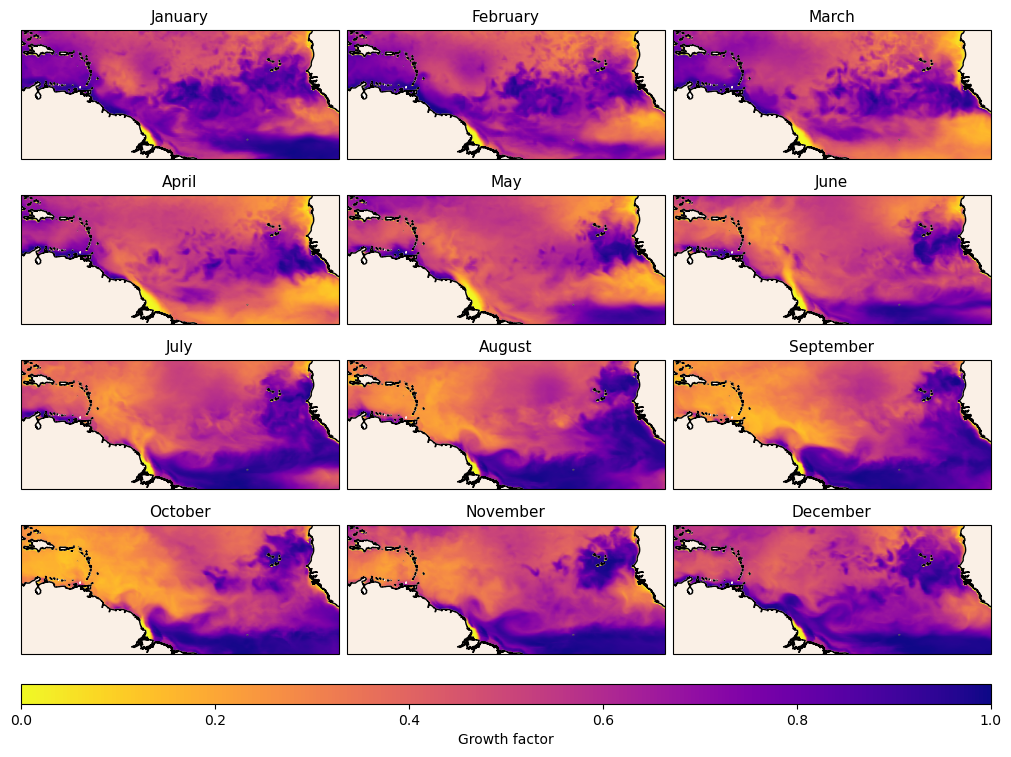

In [2]:
fig, axes = plt.subplots(4, 3, figsize=(10, 7.5), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axes.flatten()):
    ds = xr.open_zarr(f"Simulation_Basin_2024-{i+1:02d}_Eulerian.zarr")

    cscat = ax.scatter(
        ds.lon[:, 0], ds.lat[:, 0], c = ds['limitation'].mean(dim='obs').values,
        cmap='plasma_r', s=4, linewidth=0, transform=ccrs.PlateCarree(), zorder=2,
        vmin=0.0, vmax=1,
    )

    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=3, color='black')
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2, color='linen')
    ax.set_extent([-75, -11, -3, 20])
    ax.set_title(calendar.month_name[i+1], fontsize=11)

cbar = fig.colorbar(cscat, ax=axes, orientation='horizontal', pad=0.04, aspect=50, label='Growth factor')

plt.savefig("Figure7.png", bbox_inches="tight", dpi=300)
plt.show()